# Fine-tuning Stable Diffusion Model

## Packages

In [2]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF']='expandable_segments:True'
import torch
import math
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import pandas as pd
from torchvision import transforms
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline
from diffusers import AutoPipelineForText2Image
from diffusers.optimization import get_scheduler, SchedulerType
from tqdm.notebook import tqdm
from accelerate import Accelerator
from accelerate.state import AcceleratorState

from accelerate.logging import get_logger
from accelerate.utils import set_seed
import bitsandbytes as bnb
import torch.nn.functional as F
import logging, sys
import itertools
import json
import numpy as np
from torch.utils.tensorboard import SummaryWriter
from torch.distributed import destroy_process_group


/home/qzhao9/miniconda3/envs/tti/lib/python3.11/site-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
/home/qzhao9/miniconda3/envs/tti/lib/python3.11/site-packages/diffusers/models/vq_model.py:20: FutureWarning: `VQEncoderOutput` is deprecated and will be removed in version 0.31. Importing `VQEncoderOutput` from `diffusers.models.vq_model` is deprecated and this will be removed in a future version. Please use `from diffusers.models.autoencoders.vq_model import VQEncoderOutput`, instead.
  deprecate("VQEncoderOutput", "0.31", deprecation_message)
/home/qzhao9/miniconda3/envs/tti/lib/pytho

## Parameters

In [3]:
check_point = None #r'C:\Users\50183\Downloads\results (5)\fine_tuned_models\checkpoint-1000'
#'stable-diffusion-v1-5/stable-diffusion-v1-5'
base_model_name = 'CompVis/stable-diffusion-v1-4' #'stabilityai/sd-turbo'

image_data_root = r'/home/qzhao9/datasets/Kvasir-SEG'

compressor_chpt = None #r"COMP9800/model_checkpoints/compressor/compressor_weight_400E.pt"

unet_checkpoint = None

version = 'image_segV1.0'

is_train = True


## Hyperparameters

In [4]:
device = 'cuda'
learning_rate = 1e-4#5e-5
lr_scheduler_type = SchedulerType.CONSTANT.value #'constant_with_warmup' #'constant'
lr_warmup_steps=20
gradient_accumulation_steps = 8
max_train_steps = 4000
validation_steps = 20
train_text_encoder = False
train_batch_size = 1
output_dir=f'fine_tuned_models/{version}'
mixed_precision = 'fp16'
max_grad_norm = 1
save_steps = 100
max_text_token_size = 300
image_size = 768
lr_num_cycles = 3
snr_gamma = 0

In [5]:
log_writer = SummaryWriter(f'fine_tuning_logs/{version}')

In [6]:
import gc

def delete_model(pipe):
    del pipe.unet
    if train_text_encoder:
        del pipe.text_encoder
    del pipe.vae
    # del pipe.noise_scheduler
    torch.cuda.empty_cache()  # Empty the CUDA cache
    gc.collect()

## Define Dataset Classes

In [7]:
import random
import json

class KvasirDataset(Dataset):
    def __init__(self,image_name_list, image_data_root, tokenizer, img_size):
        # self.image_desc_file = image_desc_file
        self.image_data_root = image_data_root
        self.tokenizer = tokenizer
        self.image_size = img_size
        with open(os.path.join(self.image_data_root,image_name_list), 'r') as f_image_name:
            self.image_names = [n.strip() for n in f_image_name.readlines()]
        
        # self.image_desc_data = pd.read_csv(image_desc_file)
        self.len = len(self.image_names)
        self.transforms = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.CenterCrop(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5],[0.5])
        ])
        
    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_data_root, 'images', self.image_names[idx]+'.jpg')
        mask_path = os.path.join(self.image_data_root, 'masks', self.image_names[idx]+'.jpg')
        image = Image.open(image_path).convert('RGB')
        mask_img = Image.open(mask_path).convert('RGB')
        size = image.size
        image = self.transforms(image)
        mask_img = self.transforms(mask_img)
        return {'image': image, 'mask': mask_img}
    


## Load Pretrained Model stabilityai/sd-turbo

In [8]:
from peft import LoraConfig, get_peft_model

def load_base_model():
    pipe_train = AutoPipelineForText2Image.from_pretrained(base_model_name, 
                                                           dtype=torch.float16, 
                                                           variant="fp16")

    vae = pipe_train.vae
    text_encoder = pipe_train.text_encoder
    tokenizer = pipe_train.tokenizer
    unet = pipe_train.unet
    # noise_scheduler = pipe_train.scheduler
    noise_scheduler = DDPMScheduler.from_config(base_model_name, subfolder="scheduler")
    if unet_checkpoint:
        state_dict = torch.load(unet_checkpoint)
        unet.load_state_dict(state_dict)
        print(f'【{unet_checkpoint}】 is loaded into UNet!')
    else:
        print('No UNet checkpoint is provided.')

    vae.enable_slicing()
    vae.enable_tiling()

    print(f'【{base_model_name}】 is now loaded.')
    return pipe_train, vae, text_encoder, tokenizer, unet, noise_scheduler

def convert_to_trainable_lora(unet, text_encoder, train_text_encoder):
    lora_config = LoraConfig(
        r=16,
        lora_alpha=8,
        lora_dropout=0.05,
        bias="none",
        target_modules=[
            'q_proj', 'k_proj', 'v_proj', 'out_proj',
            "to_q", "to_k", "to_v", "to_out.0"
        ],
    )
    print('Applying LoRA to UNet and Text Encoder...')
    unet = get_peft_model(unet, lora_config)
    text_encoder = get_peft_model(text_encoder, lora_config) if train_text_encoder else text_encoder
    unet.print_trainable_parameters()
    if train_text_encoder: 
        text_encoder.print_trainable_parameters()
    return unet, text_encoder

In [9]:
if is_train:
    pipe_train,vae, text_encoder, tokenizer, unet, noise_scheduler = load_base_model()
    pipe_train.to(device)

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/qzhao9/miniconda3/envs/tti/lib/python3.11/site-packages/diffusers/configuration_utils.py:245: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a scheduler, please use <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>.from_pretrained(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


No UNet checkpoint is provided.
【CompVis/stable-diffusion-v1-4】 is now loaded.


In [19]:
if is_train:
    unet, text_encoder = convert_to_trainable_lora(unet, text_encoder, train_text_encoder)

Applying LoRA to UNet and Text Encoder...
trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696186561945461


In [21]:
pipe_train.unet.conv_in

Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

## Load Dataset

In [11]:
tokenizer(tokenizer.pad_token)

{'input_ids': [49406, 49407, 49407], 'attention_mask': [1, 1, 1]}

In [12]:
def collate_fn(examples):
    input_ids = [tokenizer(tokenizer.pad_token)['input_ids'] for example in examples]
    pixel_values_i = [example["image"] for example in examples]
    pixel_values_m = [example["mask"] for example in examples]

    pixel_values_i = torch.stack(pixel_values_i)
    pixel_values_i = pixel_values_i.to(memory_format=torch.contiguous_format).float()

    pixel_values_m = torch.stack(pixel_values_m)
    pixel_values_m = pixel_values_m.to(memory_format=torch.contiguous_format).float()

    input_ids = tokenizer.pad(
        {"input_ids": input_ids},
        padding="max_length",
        return_tensors="pt",
        max_length=tokenizer.model_max_length
    ).input_ids

    batch = {
        "input_ids": input_ids,
        "image": pixel_values_i,
        "mask": pixel_values_m,
    }
    return batch

# def collate_fn_diagram(examples):
#     input_ids = [example["prompt_ids"] for example in examples]
#     entity_ids = [example["entity_ids"] for example in examples]
#     relation_ids = [example["relation_ids"] for example in examples]
#     pixel_values = [example["images"] for example in examples]

#     pixel_values = torch.stack(pixel_values)
#     pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()

#     input_ids = tokenizer.pad(
#         {"input_ids": input_ids,
#          'entity_ids': entity_ids,
#         'relation_ids':relation_ids},
#         padding="max_length",
#         return_tensors="pt",
#         max_length=tokenizer.model_max_length
#     )

#     batch = {
#         "inputs": input_ids,
#         "pixel_values": pixel_values,
#     }
#     return batch

In [13]:
if is_train:
    # image_size = vae.config.sample_size
    print('VAE Sample Size',vae.config.sample_size)
    # image_size=256
    print('Image Size:', image_size)

    colon_train_ds = KvasirDataset('train.txt', image_data_root, tokenizer, image_size)
    colon_val_ds = KvasirDataset('val.txt', image_data_root, tokenizer, image_size)

    print('Dataloders splitted:', len(colon_train_ds), len(colon_val_ds))

    colon_train_dataloader = DataLoader(
        colon_train_ds, batch_size=train_batch_size, shuffle=True, collate_fn=collate_fn
    )

    colon_val_dataloader = DataLoader(
        colon_val_ds, batch_size=train_batch_size, shuffle=False, collate_fn=collate_fn
    )

    print('Dataloaders are ready.')
else:
    print('Skipping DataLoader Creation as is_train is False.')

VAE Sample Size 512
Image Size: 768
Dataloders splitted: 880 120
Dataloaders are ready.


## Define Models

In [14]:
class MedSegmentModel(nn.Module):
    def __init__(self, 
                 vae, 
                 unet, 
                 noise_scheduler, 
                 weight_dtype, 
                 train_text_encoder,
                #  scheduler,
                #  text_compressor
                ):
        super().__init__()
        
        # self.tokenizer = tokenizer
        self.vae = vae
        self.text_encoder = text_encoder
        
        self.unet = unet
        # self.unet.to(dtype=weight_dtype)
        self.noise_scheduler = noise_scheduler
        self.weight_dtype = weight_dtype
        # self.scheduler = scheduler
        # self.text_compressor = text_compressor
        # self.text_compressor.eval()
        
        self.vae.to(dtype=weight_dtype)     
        self.vae.eval() #freeze
        self.vae.requires_grad_(False)
        
        # if not train_text_encoder: 
        #     self.text_encoder.to(dtype=weight_dtype)
        #     self.text_encoder.eval() #freeze
        #     self.text_encoder.requires_grad_(False)
        # else:
        #     self.text_encoder.gradient_checkpointing_enable()
        self.unet.enable_gradient_checkpointing()
        self.input_adapter = nn.Conv2d(8, 4, kernel_size=1)

    def forward(self, batch):
        latents = self.vae.encode(batch["mask"].to(dtype=self.weight_dtype)).latent_dist.sample()
        latents = latents * self.vae.config.scaling_factor#Normalize Latent for unet

        # Sample noise
        noise = torch.randn_like(latents)
        batch_size = latents.shape[0]
        # Sample a random timestep for each image
        timesteps = torch.randint(0, 
                                  self.noise_scheduler.config.num_train_timesteps, 
                                  (batch_size,), 
                                  device=latents.device)
        timesteps = timesteps.long()

        # Add noise to the latents, forward process of diffusion
        noisy_latents = self.noise_scheduler.add_noise(latents, noise, timesteps)
        # print('Shape of mask latent:', noisy_latents.shape)
        # Get the text embedding for conditioning
        encoder_hidden_states = self.text_encoder(batch["input_ids"])[0]
        # print('Shape of text encoder hidden states:', encoder_hidden_states.shape)
        
        orign_img = self.vae.encode(batch["image"].to(dtype=self.weight_dtype)).latent_dist.sample()
        # print('Shape of orign_img latent:', orign_img.shape)
        x = torch.concat([noisy_latents,orign_img], dim=1)
        # Predict the noise residual
        x = self.input_adapter(x)
        # print('Shape after input adapter:', x.shape)
        noise_pred = self.unet(x, timesteps, encoder_hidden_states).sample

        if self.noise_scheduler.config.prediction_type == "epsilon":
            target = noise
        elif self.noise_scheduler.config.prediction_type == "v_prediction":
            target = noise_scheduler.get_velocity(latents, noise, timesteps)
            
        return noise_pred , target, timesteps
        

## Training Code

In [15]:
class EarlyStop:
    def __init__(self, max_iter):
        self.max_iteration = max_iter
        self.best_loss = None
        self.counter = 0
        self.need_stop = False
        self.loss_history=[]

    def step(self, val_loss):
        self.loss_history.append(val_loss)
        if self.best_loss is None:
            self.best_loss = val_loss
        elif self.best_loss > val_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.max_iteration:
                self.need_stop = True
        

In [16]:
loss_hist = {'train':[],'val':[]}

def compute_snr(scheduler, timesteps):
    alphas_cumprod = scheduler.alphas_cumprod.to(timesteps.device)
    alphas_cumprod = alphas_cumprod[timesteps].float()
    snr = alphas_cumprod / (1 - alphas_cumprod)
    return snr

def training_function(text_encoder, vae, unet,noise_scheduler, train_dataloader, val_dataloader):
    """
    The training function."""
    set_seed(27)
    accelerator = Accelerator(
        gradient_accumulation_steps=gradient_accumulation_steps,
        mixed_precision=mixed_precision,
        # cpu_offload=True,
    )
    accelerator.print(f'{AcceleratorState()}')
    print('Available Device: ', accelerator.device)
    print('accelerator.mixed_precision: ', accelerator.mixed_precision)
    print('accelerator.gradient_accumulation_steps: ', accelerator.gradient_accumulation_steps)
    device = accelerator.device
 
    # Use 8-bit Adam for lower memory usage or to fine-tune the model in 16GB GPUs
    if accelerator.device.type == 'cuda':
        optimizer_class = bnb.optim.AdamW8bit
    else:
        optimizer_class = torch.optim.AdamW

    params_to_optimize = (
        itertools.chain(unet.parameters(), text_encoder.parameters()) if train_text_encoder else unet.parameters()
    )
    
    optimizer = optimizer_class(
        params_to_optimize,
        lr=learning_rate,
    )

    lr_scheduler = get_scheduler(
        lr_scheduler_type,
        optimizer=optimizer,
        num_warmup_steps=lr_warmup_steps, # * gradient_accumulation_steps,
        num_training_steps=max_train_steps, # * gradient_accumulation_steps,
        num_cycles=lr_num_cycles,
        step_rules='4:1000,3:2000,2:3000,1:4000,0.5'
    )
    print('lr scheduler:', lr_scheduler_type)
    print('optimizer_class:', optimizer_class)
    
    hparam_dict = {
            'learning_rate': learning_rate,
            'lr_warmup_steps': lr_warmup_steps,
            'train_batch_size': train_batch_size,
            'gradient_accumulation_steps': gradient_accumulation_steps,
            'max_train_steps': max_train_steps,
            'train_text_encoder': 'True' if train_text_encoder else 'False',
            'lr_scheduler_type' : lr_scheduler_type,
            'lr_cycles': lr_num_cycles,
            'optimizer_class' : str(optimizer_class),
            'output_dir': output_dir,
            'device': str(accelerator.device),
            'image_size': image_size,
            'max_grad_norm': max_grad_norm,
        }

    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    # We need to recalculate our total training steps as the size of the training dataloader may have changed.
    num_update_steps_per_epoch = math.ceil(len(train_dataloader) / gradient_accumulation_steps)
    num_train_epochs = math.ceil(max_train_steps / num_update_steps_per_epoch)
    
    total_batch_size = train_batch_size * accelerator.num_processes * gradient_accumulation_steps
    
    print("total batch size:",total_batch_size)
    print("***** Running training *****")
    print(f"  Instantaneous batch size per device = {train_batch_size}")
    print(f"  Total train batch size (w. parallel, distributed & accumulation) = {total_batch_size}")
    print(f"  Gradient Accumulation steps = {gradient_accumulation_steps}")
    print(f"  Total optimization steps = {max_train_steps}")
    # Only show the progress bar once on each machine.
    progress_bar = tqdm(range(max_train_steps), disable=not accelerator.is_local_main_process)
    progress_bar.set_description("Steps")

    global_step = 0

    early_stopping = EarlyStop(max_iter=max_train_steps)

    # token_vocab_size = text_encoder.config.vocab_size #CLIPTextModel
    # compressor = TokenCompressor(max_text_token_size, token_vocab_size)

    # if compressor_chpt:
    #     comp_state_dict = torch.load(compressor_chpt, map_location=device)
    #     compressor.load_state_dict(comp_state_dict)
    # compressor.eval()
    # compressor.to('cpu') #

    unet.to(memory_format=torch.channels_last)
    
    model = MedSegmentModel(vae, unet, 
                          noise_scheduler, weight_dtype, text_encoder
                          )
    try:
        import xformers
        unet.enable_xformers_memory_efficient_attention()
        print('Xformers is enabled.')
        hparam_dict['Xformers enabled']= 1
    except:
        print('Xformers is not available.')
        hparam_dict['Xformers enabled']= 0

    print(hparam_dict)
    log_writer.add_hparams(hparam_dict,{})

    model.to(accelerator.device)


    model, optimizer, train_dataloader, val_dataloader, lr_scheduler = accelerator.prepare(model, 
                                                                           optimizer, 
                                                                           train_dataloader, 
                                                                           val_dataloader,
                                                                           lr_scheduler)
    os.makedirs(output_dir, exist_ok=True)
    
    model.train()
    
    torch.backends.cuda.matmul.allow_tf32 = True

    for epoch in range(num_train_epochs):
        if early_stopping.need_stop:
            break
        accumulate_loss = []
        for step, batch in enumerate(train_dataloader):
            with accelerator.accumulate(unet):
                noise_pred, target, timesteps = model(batch)
                if not snr_gamma:
                    loss = F.mse_loss(noise_pred.float(), target.float(), reduction="mean")
                else:
                    # Compute SNR
                    snr = compute_snr(noise_scheduler, timesteps)
                    loss = torch.mean( torch.minimum(snr, torch.tensor(snr_gamma,device=snr.device)) * 
                                      F.mse_loss(noise_pred.float(), target.float(), reduction="none"), dim=[1,2,3] )

                accelerator.backward(loss)
                accumulate_loss.append(loss.detach().item())
                if accelerator.sync_gradients:
                    params_to_optimize = ( itertools.chain(unet.parameters(), text_encoder.parameters()) 
                                          if train_text_encoder 
                                          else unet.parameters() )
                    accelerator.clip_grad_norm_(params_to_optimize, max_grad_norm)

                    
                    optimizer.step()
                    optimizer.zero_grad()
                    
                    log_writer.add_scalar('lr_scheduer', 
                                          lr_scheduler.get_last_lr()[0], 
                                          global_step)
                    lr_scheduler.step()

                if early_stopping.need_stop:
                    print("Early stopping triggered")
                    break
                
            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1

                if global_step % save_steps == 0:
                    if accelerator.is_main_process:
                        unwrapped_unet = accelerator.unwrap_model(model.unet)
                        # save_path = os.path.join(output_dir, f"checkpoint-{global_step}.pt")
                        # accelerator.save(unwrapped_unet.state_dict(), save_path)
                        model.unet.save_pretrained(os.path.join(output_dir, f"unet{-global_step}"))
                        if train_text_encoder:
                            model.text_encoder.save_pretrained(os.path.join(output_dir,f'text_encoder_{global_step}'))
                        print(f'checkpoint {global_step} saved.')
                        log_writer.flush()
                if global_step % validation_steps == 0:
                    # Validation Step
                    model.eval()
                    with torch.no_grad():
                        val_loss_hist = []
                        for val_step, val_batch in enumerate(val_dataloader):
                            val_noise_pred, val_target, timestes = model(val_batch)
                            if not snr_gamma:
                                val_loss = F.mse_loss(val_noise_pred.float(), val_target.float(), reduction="mean")
                            else:
                                # Compute SNR
                                snr = compute_snr(noise_scheduler, timestes)
                                val_loss = torch.mean( torch.minimum(snr, torch.tensor(snr_gamma,device=snr.device)) * 
                                                      F.mse_loss(val_noise_pred.float(), val_target.float(), reduction="none"), dim=[1,2,3] )
                            val_loss_hist.append(val_loss.detach().item())
                            # if val_step >= 10:
                            #     break # only 10 batches for validation
                        val_loss = np.mean(val_loss_hist)
                        early_stopping.step(val_loss)
                        loss_hist['val'].append(val_loss)
                        log_writer.add_scalar("Loss/val", val_loss, global_step)
                    
                    model.train()
                bt_loss = np.mean(accumulate_loss)
                log_writer.add_scalar("Loss/train", bt_loss, global_step)
                # loss_hist.append((bt_loss, val_loss))
                loss_hist['train'].append(bt_loss)
                
                
                accumulate_loss.clear()
                
            logs = {"loss": round(loss.detach().item(),3)}
            progress_bar.set_postfix(**logs)

            if global_step >= max_train_steps:
                break
        del noise_pred, target
        torch.cuda.empty_cache()
        
        accelerator.wait_for_everyone()

    # Create the pipeline using using the trained modules and save it.
    if accelerator.is_main_process:
        unwrapped_unet = accelerator.unwrap_model(model.unet)
        # save_path = os.path.join(output_dir, f"checkpoint-{global_step}.pt")
        # accelerator.save(unwrapped_unet.state_dict(), save_path)
        model.unet.save_pretrained(os.path.join(output_dir, f"unet{global_step}"))
        if train_text_encoder:
            model.text_encoder.save_pretrained(os.path.join(output_dir,f'text_encoder_{global_step}'))
        print(f'checkpoint {global_step} saved.')
        log_writer.flush()

    # destroy_process_group() 
    accelerator.end_training()
    return loss_hist

In [17]:
import matplotlib.pyplot as plt
def print_loss_hist(loss_hist):
    fig, axes = plt.subplots(2, 1, figsize=(18, 9))

    # Training loss
    axes[0].plot(
        loss_hist['train'],
        label="Training Loss",
        linewidth=2
    )
    axes[0].set_xlabel("Steps")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss Curve")
    axes[0].legend()
    axes[0].grid(True)

    # Validation loss
    axes[1].plot(
        loss_hist['val'],
        label="Validation Loss",
        linewidth=2
    )
    axes[1].set_xlabel("Steps")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Validation Loss Curve")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("loss_curve.png", dpi=600)
    plt.show()


In [ ]:
import traceback
from accelerate import notebook_launcher
if is_train:
    try:
        # loss_hist = training_function(text_encoder, vae, unet, colon_train_dataloader)
        notebook_launcher(training_function, 
                    args=(text_encoder, vae, unet, noise_scheduler, colon_train_dataloader, colon_val_dataloader), 
                    num_processes=1, 
                    mixed_precision="fp16")
    except:
        traceback.print_exc()
        print('Error occured while training.')
        raise "Failed"
    log_writer.close()
    print_loss_hist(loss_hist)

Launching training on one GPU.
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

Available Device:  cuda
accelerator.mixed_precision:  fp16
accelerator.gradient_accumulation_steps:  8
lr scheduler: constant
optimizer_class: <class 'bitsandbytes.optim.adamw.AdamW8bit'>
total batch size: 8
***** Running training *****
  Instantaneous batch size per device = 1
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 8
  Total optimization steps = 4000


/home/qzhao9/miniconda3/envs/tti/lib/python3.11/site-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


  0%|          | 0/4000 [00:00<?, ?it/s]

Xformers is not available.
{'learning_rate': 0.0001, 'lr_warmup_steps': 20, 'train_batch_size': 1, 'gradient_accumulation_steps': 8, 'max_train_steps': 4000, 'train_text_encoder': 'False', 'lr_scheduler_type': 'constant', 'lr_cycles': 3, 'optimizer_class': "<class 'bitsandbytes.optim.adamw.AdamW8bit'>", 'output_dir': 'fine_tuned_models/image_segV1.0', 'device': 'cuda', 'image_size': 768, 'max_grad_norm': 1, 'Xformers enabled': 0}


In [ ]:
# Free up some memory after training
if is_train:
    for param in itertools.chain(unet.parameters(), text_encoder.parameters()):
        if param.grad is not None:
            del param.grad  # Free some memory

    del unet
    del text_encoder
    del vae
    del noise_scheduler
    
    torch.cuda.empty_cache()  # Empty the CUDA cache
    gc.collect()

## Evaluate

In [ ]:
# import torch
# from diffusers import AutoPipelineForText2Image
# # check_point = r'C:\Users\50183\Downloads\results (5)\fine_tuned_models\checkpoint-10000'
# base_model_name = 'stabilityai/sd-turbo'
# pipe = AutoPipelineForText2Image.from_pretrained(base_model_name, dtype=torch.float16, variant="fp16")
# pipe = pipe.to('cuda')

In [ ]:
# Load the full FT checkpoint
ckpt = r"fine_tuned_models/data_v4.8/checkpoint-8000.pt"
ckpt = r'/home/qzhao9/Downloads/checkpoint-2000(1).pt'

def load_unet_checkpoint(pipe, ckpt):
  state_dict_diag_unet = torch.load(ckpt, map_location='cuda')
  pipe.unet.load_state_dict(state_dict_diag_unet)

In [ ]:
# Load LoRA 
from peft import PeftModel

def load_lora(pipe, unet_lora_path, train_text_encoder=False,text_encoder_lora_path=None):
    pipe.unet = PeftModel.from_pretrained(
        pipe.unet,
        unet_lora_path
    )
    
    if train_text_encoder:
        pipe.text_encoder = PeftModel.from_pretrained(
            pipe.text_encoder,
            text_encoder_lora_path
        )


Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

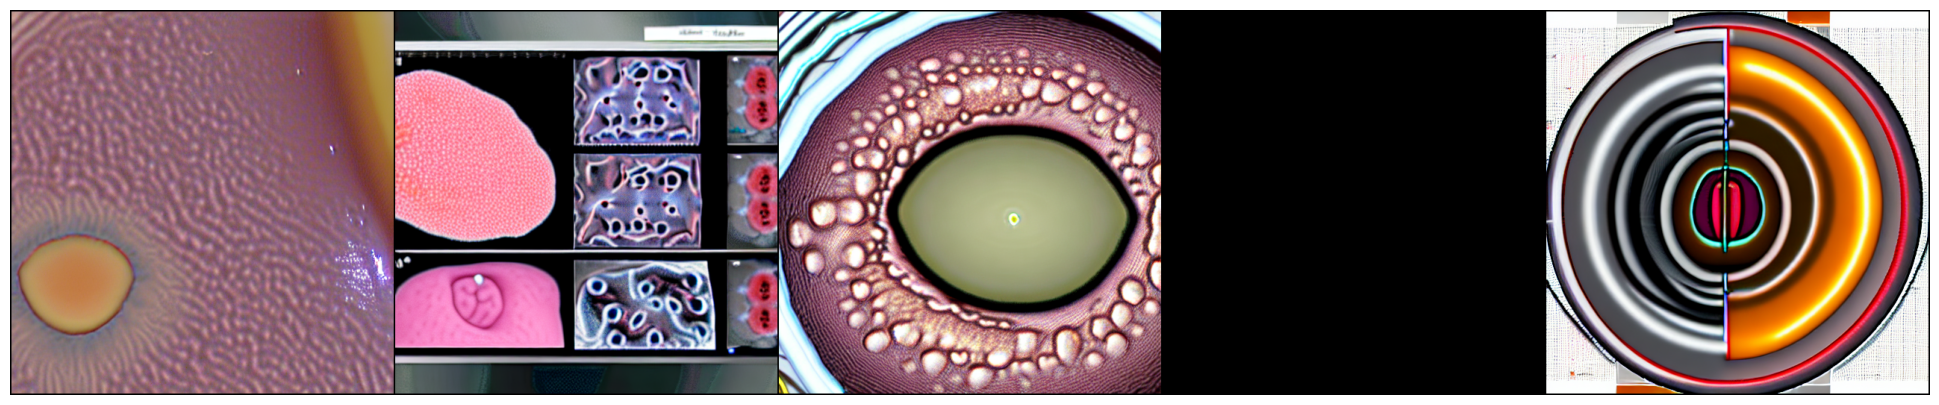

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


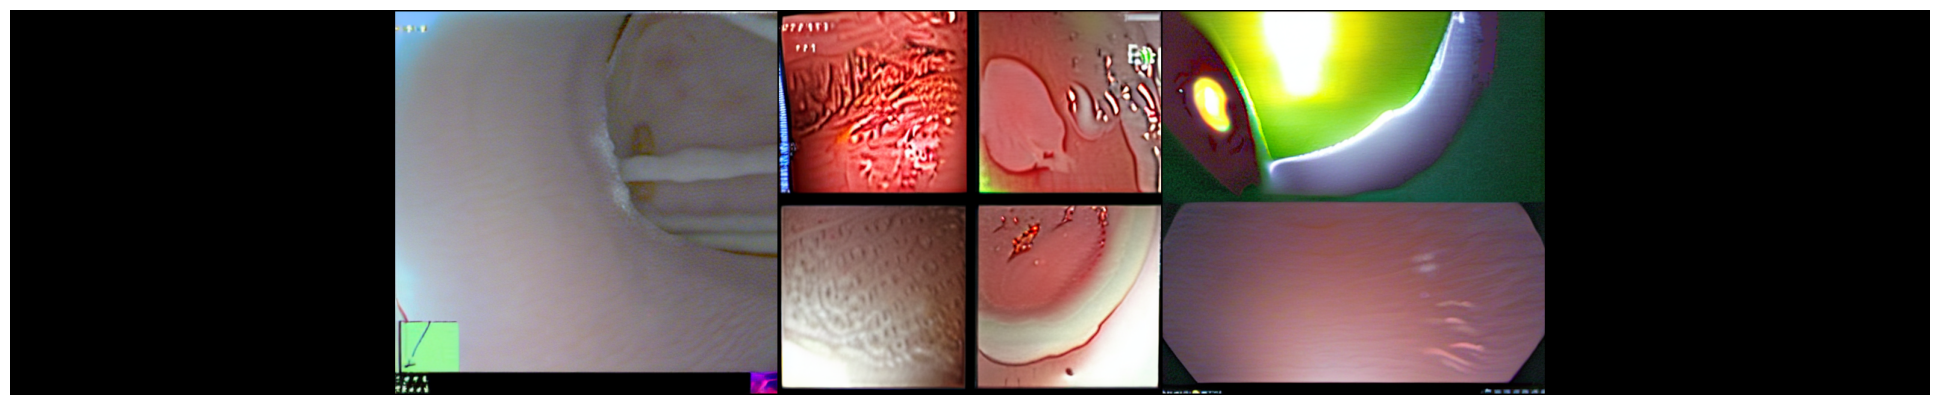

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


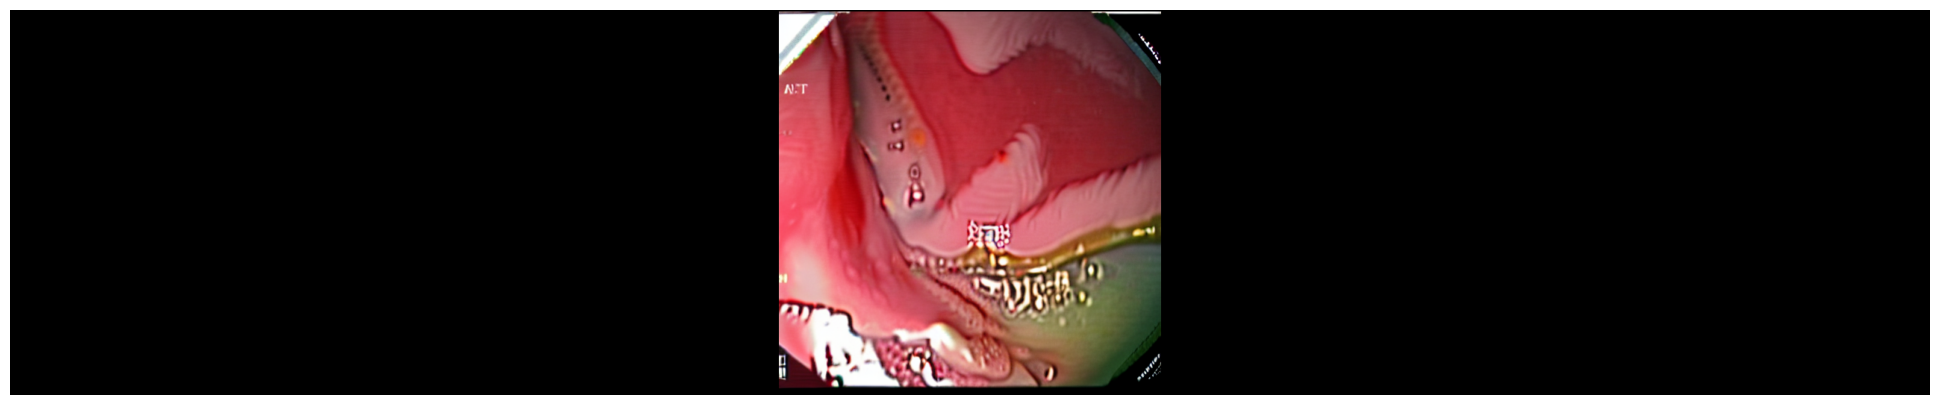

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


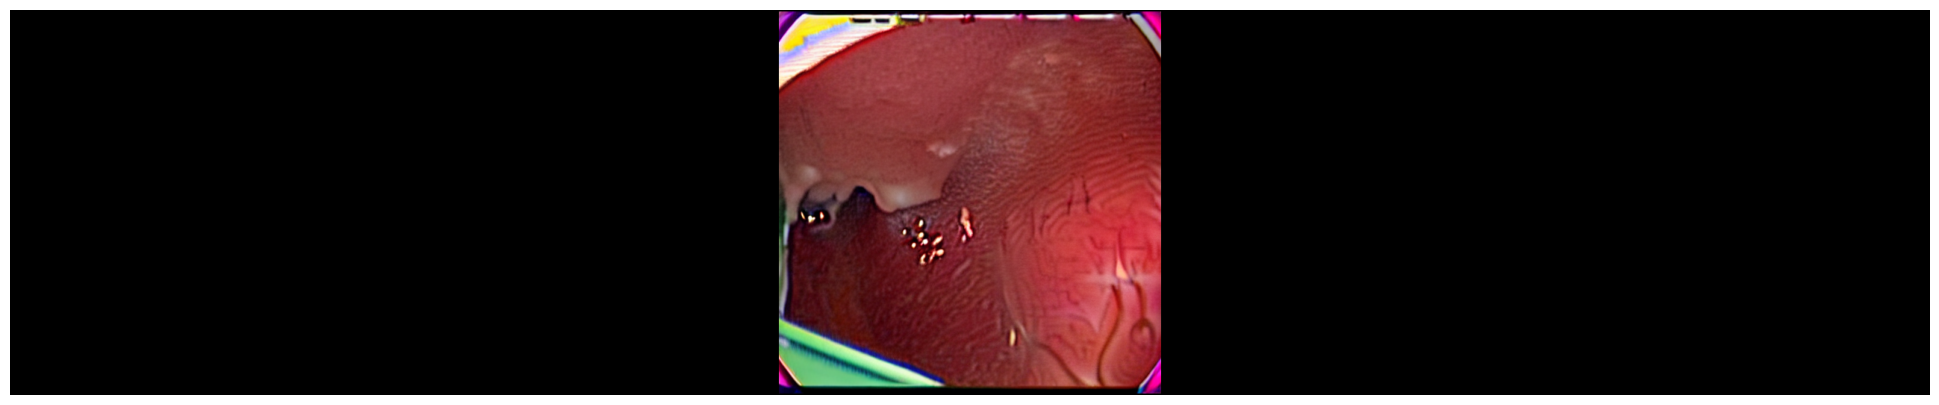

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


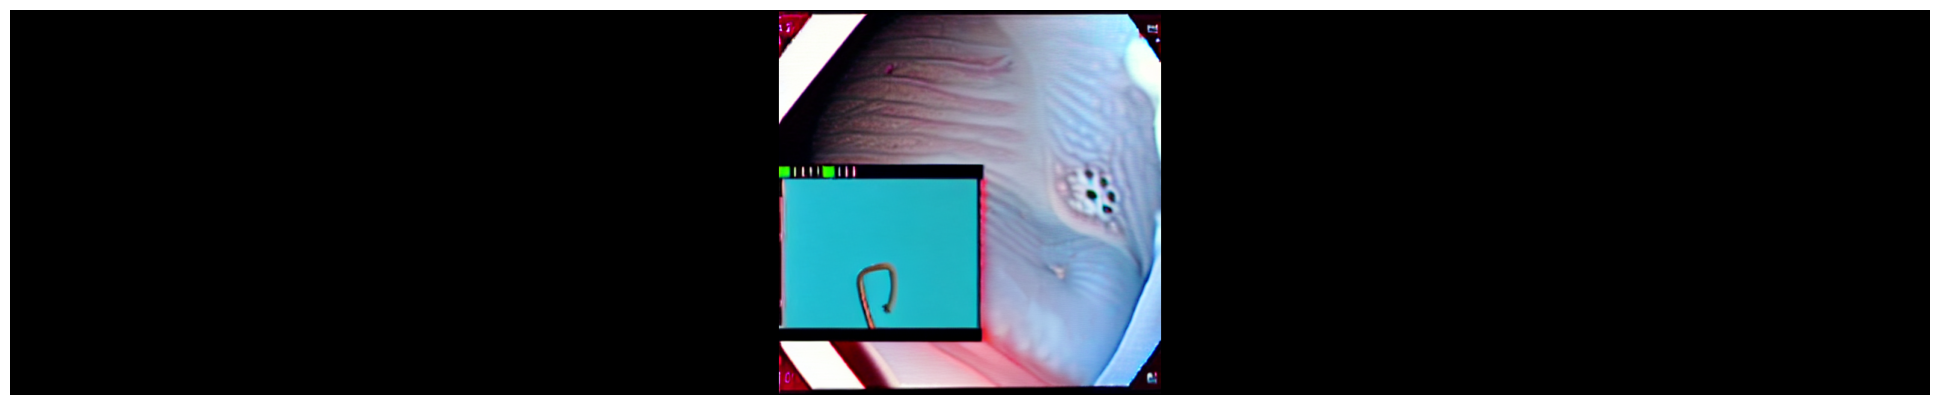

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

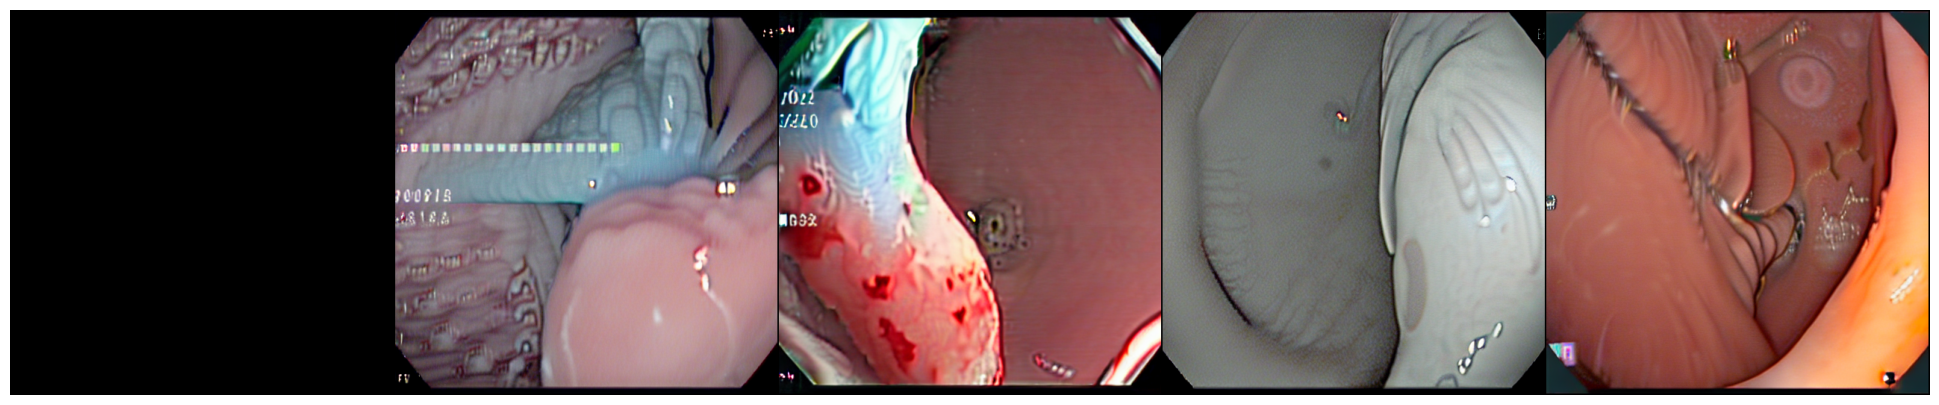

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

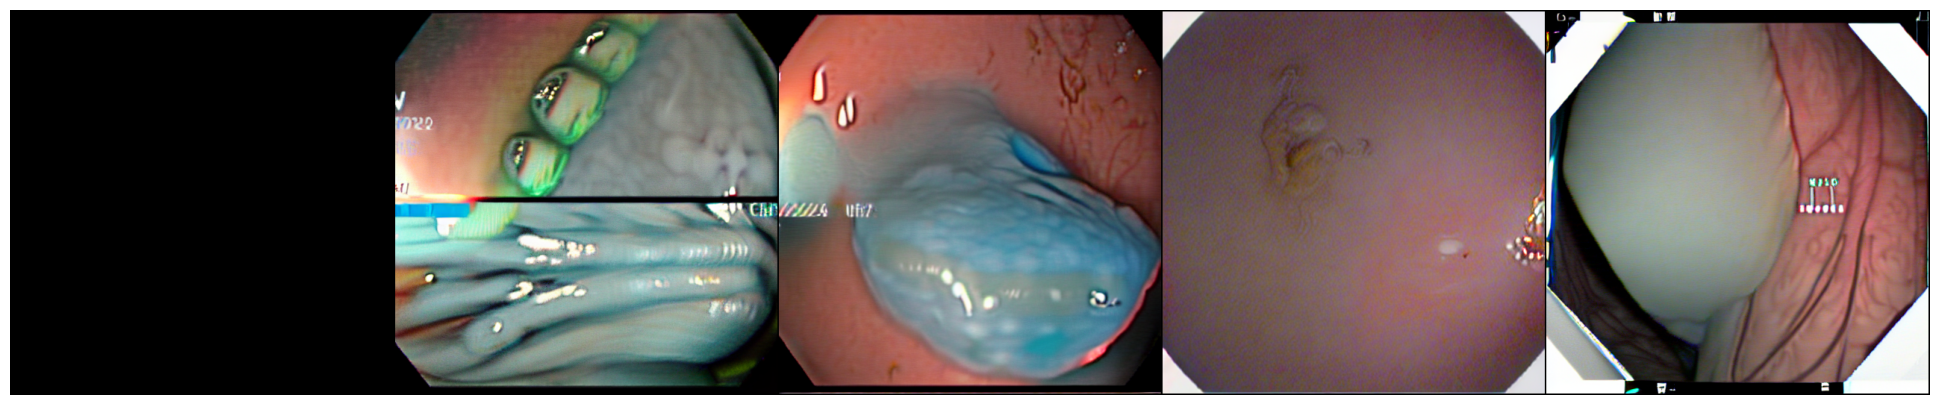

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

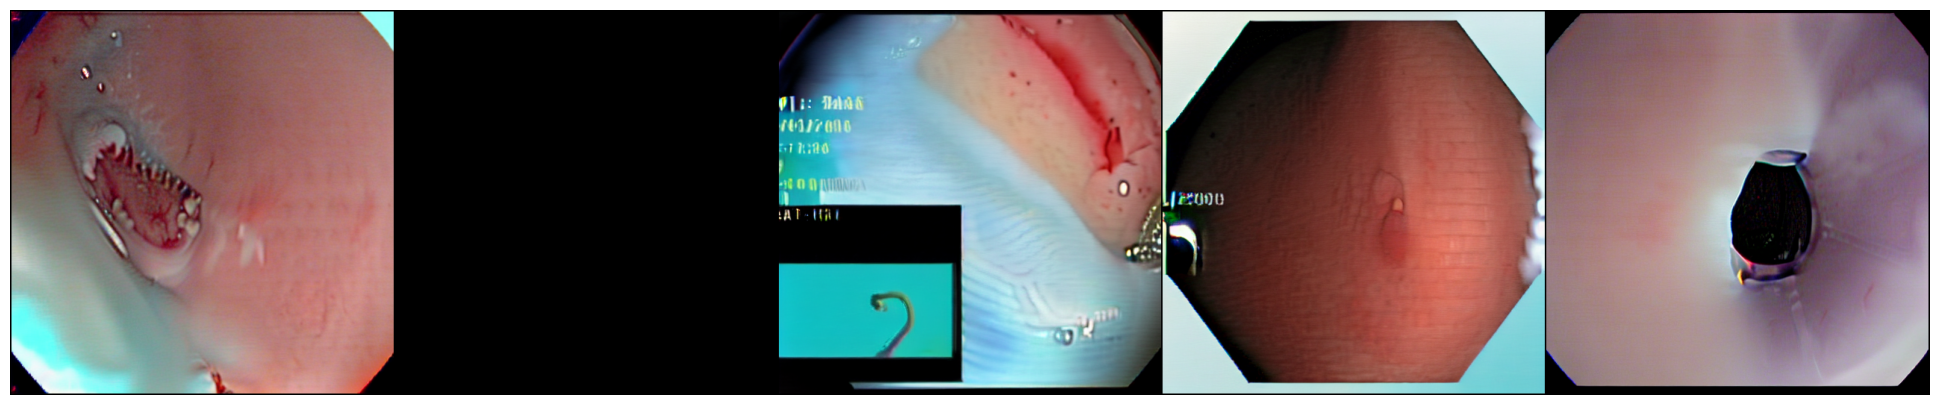

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

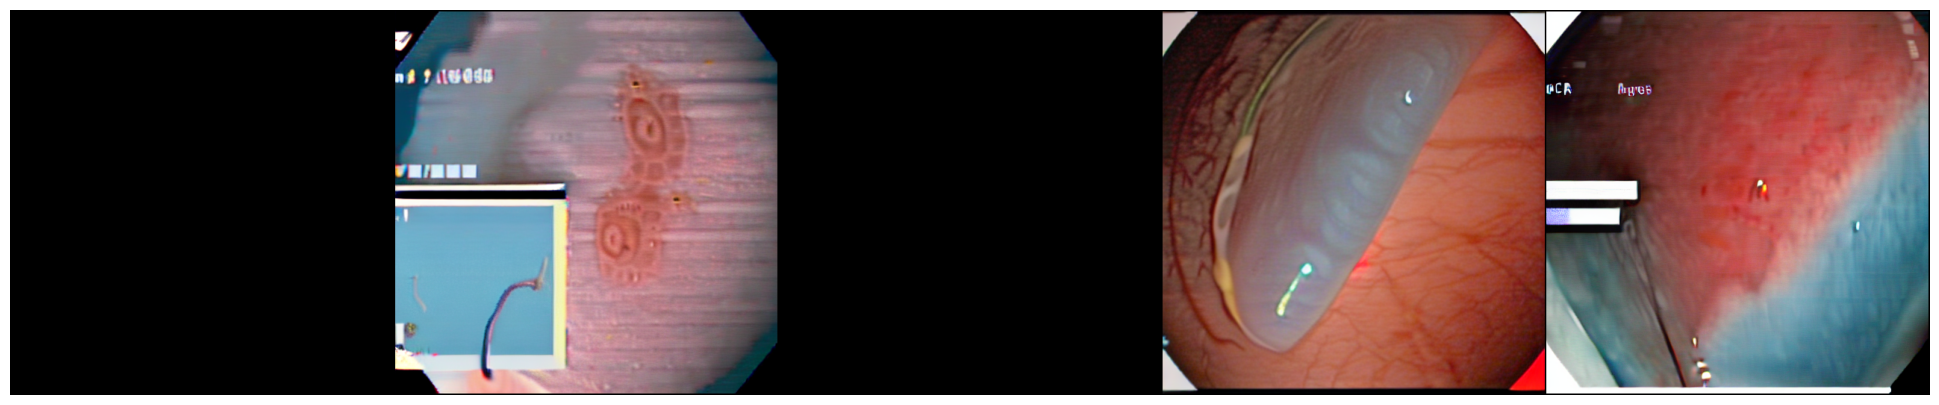

In [ ]:
# Evaluation  LoRA 
train_text_encoder = False
# version = 'data_v4.12'
steps = [100,500,1000,1500,2000,2500,3000,3500,4000]
for step in steps:
    pipe = AutoPipelineForText2Image.from_pretrained(base_model_name, dtype=torch.float16, variant="fp16")
    pipe = pipe.to('cuda')
    if steps:
        load_lora(pipe, 
                f"/home/qzhao9/code/9800/gradproj/experiments/fine_tuned_models/{version}/unet-{step}",
                train_text_encoder,
                f"/home/qzhao9/code/9800/gradproj/experiments/fine_tuned_models/{version}/text_encoder_{step}" 
                )
    evaluate_model(pipe, eval_prompts, eval_cfg,step, output_dir+f'/lora_samples_{version}_{step}.png')

    delete_model(pipe)

In [ ]:
# delete_model(pipe)

In [ ]:
## Load Early Version Fine Tuning Checkpoint
# import torch
# from diffusers import AutoPipelineForText2Image
# base_model_name = '/home/qzhao9/code/fine_tuned_models/results/fine_tuned_models/checkpoint-1000'
# pipe = AutoPipelineForText2Image.from_pretrained(base_model_name, torch_dtype=torch.float16)
# pipe = pipe.to('cuda')

In [ ]:
# prompt='an endoscopic image of dyed resection margins shows a close - up view of a surgical site within the gastrointestinal tract, likely the stomach or duodenum. the resection margins are dyed in a specific color, which appears to be a shade of blue.'
# # prompt='An endoscopic image of polyps typically shows the polyps on the mucosa of the gastrointestinal tract. The polyps appears as small, reddish-brown or yellowish-brown growths. ' \
# # 'The surrounding mucosa is a lighter shade of red, and the surface texture of the polyps can be slightly rough.'
# # prompt = 'A diagram showing Earth''s position in relation to the Sun during different seasons and equinoxes.'
# prompt = 'a realistic endoscopic image of a dyed polyp on the mucosa of the gastrointestinal tract. '


In [ ]:
# with torch.no_grad():
#     image = pipe(
#         prompt,
#         negative_prompt="",
#         num_inference_steps=50,
#         guidance_scale=7.5,
#     ).images[0]
# image

In [ ]:
# del pipe
# torch.cuda.empty_cache()
# import gc
# gc.collect()

In [ ]:
# token_vocab_size = 49408 #CLIPTextModel
# compressor_chpt = r"C:\COMP9800\model_checkpoints\compressor\compressor_weight_400E.pt"

# comp_state_dict = torch.load(compressor_chpt, map_location=device)

# compressor = TokenCompressor(max_text_token_size, token_vocab_size)

# compressor.load_state_dict(comp_state_dict)

# ft_unet = UNet2DConditionModel.from_pretrained(
#     check_point, subfolder="unet"
# )

# model = MedQATTIModel(tokenizer, vae, text_encoder, ft_unet, 
#                         noise_scheduler, torch.float32, 
#                         train_text_encoder,compressor)



# Explore Diagram Dataset

In [ ]:
# import json

# ai2d_caption_gpt4 = r'C:\COMP9800\Dataset\AI2D-Caption\ai2d_caption_gpt4v.json'

# with open(ai2d_caption_gpt4,'r') as f:
#     captions = json.load(f)
# image_captions=[]
# no_cap_image=[]
# for cap in captions:
#     if 'caption' not in cap:
#         no_cap_image.append(cap['image'])
#         continue
#     image_captions.append({'img':cap['image'], 'caption':cap['caption']})

In [ ]:
# import torch, xformers

# print(torch.__version__)
# print(torch.version.cuda)
# print(xformers.__version__)

In [ ]:
# from diffusers import StableDiffusionPipeline
# from diffusers.models.attention_processor import XFormersAttnProcessor

# pipe = StableDiffusionPipeline.from_pretrained(
#     'stable-diffusion-v1-5/stable-diffusion-v1-5', torch_dtype=torch.float16
# )
# pipe = pipe.to('cuda')  

# # pipe.unet.enable_xformers_memory_efficient_attention()

# print('Xformers is successfully enabled.', any(isinstance(p, XFormersAttnProcessor) for p in pipe.unet.attn_processors.values()))

In [ ]:
# prompt='a photo of a polyp on the wall of a colon tract.'
# with torch.no_grad():
#     image = pipe(
#         prompt,
#         # negative_prompt="",
#         # num_inference_steps=50,
#         guidance_scale=7.5,
#     ).images[0]
# image